In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform, FastKerrEccentricEquatorialAccretionFlux

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, SuperKludgeFlux,  KerrEccEqAccFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import YRSID_SI

from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_separatrix


from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product, fishinv
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt
import corner

try:
    import cupy as cp
    cp.cuda.runtime.getDeviceCount()      # importing cupy is not enough, the driver must work too
    xp, use_gpu = cp, True
except Exception as exc:
    xp, use_gpu = np, False
    print(f"[INFO] No usable GPU ({type(exc).__name__}), falling back to NumPy on CPU.")

print(f"[INFO] use_gpu = {use_gpu}")

startup
[INFO] use_gpu = True


In [2]:
def evolve_inspiral(m1, m2, a, p0, e0,T_obs, xI0=1.0 ,
                        flux_class=KerrEccEqAccFlux, add_args=(), full=False):


        traj = EMRIInspiral(func=flux_class)
        # KerrEccEqFlux returns t + 6 arrays, SuperKludgeFlux returns t + 8
        # (it also evolves delta_m1, delta_a), so unpack by position not by count.
        out_traj = traj(m1, m2, a, p0, e0, xI0, *add_args, T=T_obs)
        t, p, e, xI = out_traj[0], out_traj[1], out_traj[2], out_traj[3]
        Phi_phi, Phi_r, Phi_theta = out_traj[4], out_traj[5], out_traj[6]

        sep = float(get_separatrix(a, e[-1], xI0))
        t_yr = float(t[-1]) / YRSID_SI
        # plunge = the integrator stopped at the separatrix rather than at T_obs
        plunged = bool(t_yr < 0.999 * T_obs)
        try:
            p0_plunge = float(get_p_at_t(traj, T_obs, [m1, m2, a, e0, xI0] + list(add_args),
                                         bounds=None))
        except Exception:
            p0_plunge = float("nan")

        out = dict(e0=float(e0), e_final=float(e[-1]),
                   p0=float(p0), p_final=float(p[-1]),
                   separatrix=sep, dp_to_separatrix=float(p[-1]) - sep,
                   t_final_yr=t_yr, plunged=plunged, p0_for_plunge=p0_plunge,
                   n_points=int(len(t)))
        if full:
            out.update(t=t, p=p, e=e, xI=xI, Phi_phi=Phi_phi, Phi_r=Phi_r)
        return out

In [3]:
a = 0.0
m1 = 1e6
m2 = 2*1e3
p0 = 24.35


Phi_phi0 = 1.0
Phi_theta0 = 0.0
Phi_r0 = 1.0

qS = np.pi/4
phiS = np.pi/3

qK = np.pi/6
phiK = np.pi/8

dist = 16.344

e0 = 0.2
Y0 = 1.0
# Duque et al. quote the disk surface density in g/cm^2; the ODE works in geometric
# units (G = c = M = 1), where Sigma enters as Sigma * a_m^2 against M = 1.  The
# conversion is Sigma_geo = Sigma_cgs * (G m1 / c^2)^2 / m1, i.e. a length^2 as well
# as the mass -- dividing by the solar mass alone leaves it ~1e11 times too small.
MSUN_G = 1.98892e33                                    # solar mass in g
C_CM_S = 2.99792458e10                                 # c in cm/s
R_G_CM = m1 * MTSUN_SI * C_CM_S                        # G m1 / c^2 in cm
SIGMA_CGS_TO_GEO = R_G_CM ** 2 / (m1 * MSUN_G)         # 1.097e-17 for m1 = 1e6 Msun

# Sigma0_cgs = 5.25e5                                    # paper value, g/cm^2
Sigma0_cgs = 5.25e5                                     # paper value, g/cm^2
Sigma0, h0, Sigma_p = Sigma0_cgs * SIGMA_CGS_TO_GEO, 0.025, -1.5
print(f"[DISK] Sigma0 = {Sigma0_cgs:.3e} g/cm^2 = {Sigma0:.4e} (geometric)")


[DISK] Sigma0 = 5.250e+05 g/cm^2 = 5.7555e-12 (geometric)


In [4]:
param_names_14 = ["m1", "m2", "a", "p0", "e0", "xI0", "dist", "qS", "phiS",
                  "qK", "phiK", "Phi_phi0", "Phi_theta0", "Phi_r0"]

source_params = dict(m1=m1, m2=m2, a=a, p0=p0, e0=e0, xI0=Y0, dist=dist,
                     qS=qS, phiS=phiS, qK=qK, phiK=phiK,
                     Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0)


def env_tail(environmental_included):
    """The 3  extra KerrEccEqFlux arguments, positional, as ResponseWrapper wants them."""
    if not environmental_included:
        return []
    return [Sigma0, h0, Sigma_p]


def env_apa(environmental_included):
    """The same 3 arguments as a dict, which is how SEF wants them (appended in dict order)."""
    if not environmental_included:
        return {}
    return dict(Sigma0=Sigma0, h0=h0, Sigma_p=Sigma_p)

def wave_params(environmental_included):
    return [source_params[n] for n in param_names_14] + env_tail(environmental_included)


print("[GR ]", wave_params(False))
print("[ENV]", wave_params(True))

[GR ] [1000000.0, 2000.0, 0.0, 24.35, 0.2, 1.0, 16.344, 0.7853981633974483, 1.0471975511965976, 0.5235987755982988, 0.39269908169872414, 1.0, 0.0, 1.0]
[ENV] [1000000.0, 2000.0, 0.0, 24.35, 0.2, 1.0, 16.344, 0.7853981633974483, 1.0471975511965976, 0.5235987755982988, 0.39269908169872414, 1.0, 0.0, 1.0, 5.755491870327513e-12, 0.025, -1.5]


In [5]:
# The test runs to plunge, so T comes from the trajectory rather than being hardcoded.
# T_SAFETY < 1 backs off a hair from the separatrix: at exactly T = t_plunge, the Fisher
# stencil steps that increase m2 plunge before T and SEF's plunge_check rejects them.
# Set T_SAFETY = 1.0 to sit exactly at plunge.
T_SAFETY = 0.99
insp_gr = evolve_inspiral(m1, m2, a, p0, e0, T_obs=10, xI0=Y0, flux_class=KerrEccEqAccFlux, add_args=env_tail(True))
T_plunge = insp_gr["t_final_yr"]
T = T_SAFETY * T_plunge
dt = 5
nchannels = 3

# Inner products are restricted to this band. Everything -- overlap, SNR, both Fishers --
# uses the same mask, so the two cases are scored identically.
F_MIN, F_MAX = 1e-5, 1e-1

print(f"[TRAJ] plunged = {insp_gr['plunged']}, t_plunge = {T_plunge:.6f} yr, "
      f"p_final = {insp_gr['p_final']:.5f}, separatrix = {insp_gr['separatrix']:.5f}")
print(f"[CONF] T = {T:.6f} yr ({T_SAFETY:g} x t_plunge), dt = {dt} s, nchannels = {nchannels}")
print(f"[CONF] Nyquist = {1 / (2 * dt):.4f} Hz, N samples ~ {int(T * YRSID_SI / dt):,d}")
print(f"[CONF] band = [{F_MIN:.1e}, {F_MAX:.1e}] Hz"
      + ("  -- f_max is at or above Nyquist, so the upper edge does nothing"
         if F_MAX >= 1 / (2 * dt) else ""))

[TRAJ] plunged = True, t_plunge = 0.506292 yr, p_final = 6.08556, separatrix = 6.08356
[CONF] T = 0.501229 yr (0.99 x t_plunge), dt = 5 s, nchannels = 3
[CONF] Nyquist = 0.1000 Hz, N samples ~ 3,163,574
[CONF] band = [1.0e-05, 1.0e-01] Hz  -- f_max is at or above Nyquist, so the upper edge does nothing


## Comparison between inspirals with and without environmental effects

Compare `e_dot`, `p_dot`, `Phi_phi` and `Phi_r` for the same initial conditions and the
same `T`, `dt` and flux model. The only difference is that one has environmental effects
and the other does not.


[ENV] Sigma0 = 5.7555e-12 (geometric), h0 = 0.025, Sigma_p = -1.5
[RUN] T = 0.501229 yr | env: N = 46, t_end = 0.501229 yr | vac: N = 45, t_end = 0.501229 yr
 quantity       env final       vac final    final diff    max |diff|   final rel
        p   9.4761630e+00   9.4619985e+00  +1.41645e-02   1.41645e-02  +1.497e-03
        e   4.5583641e-02   4.5510897e-02  +7.27441e-05   7.27441e-05  +1.598e-03
     pdot  -9.1130921e-06  -9.1704778e-06  +5.73857e-08   5.73857e-08  -6.258e-03
     edot  -6.5607708e-08  -6.5972217e-08  +3.64509e-10   3.64509e-10  -5.525e-03
  Phi_phi   3.7697682e+04   3.7705071e+04  -7.38910e+00   7.38910e+00  -1.960e-04
    Phi_r   3.0598123e+04   3.0601767e+04  -3.64406e+00   3.64406e+00  -1.191e-04
[DEPHASING] dPhi_phi = -7.389101e+00 rad, dPhi_r = -3.644061e+00 rad over 0.5012 yr


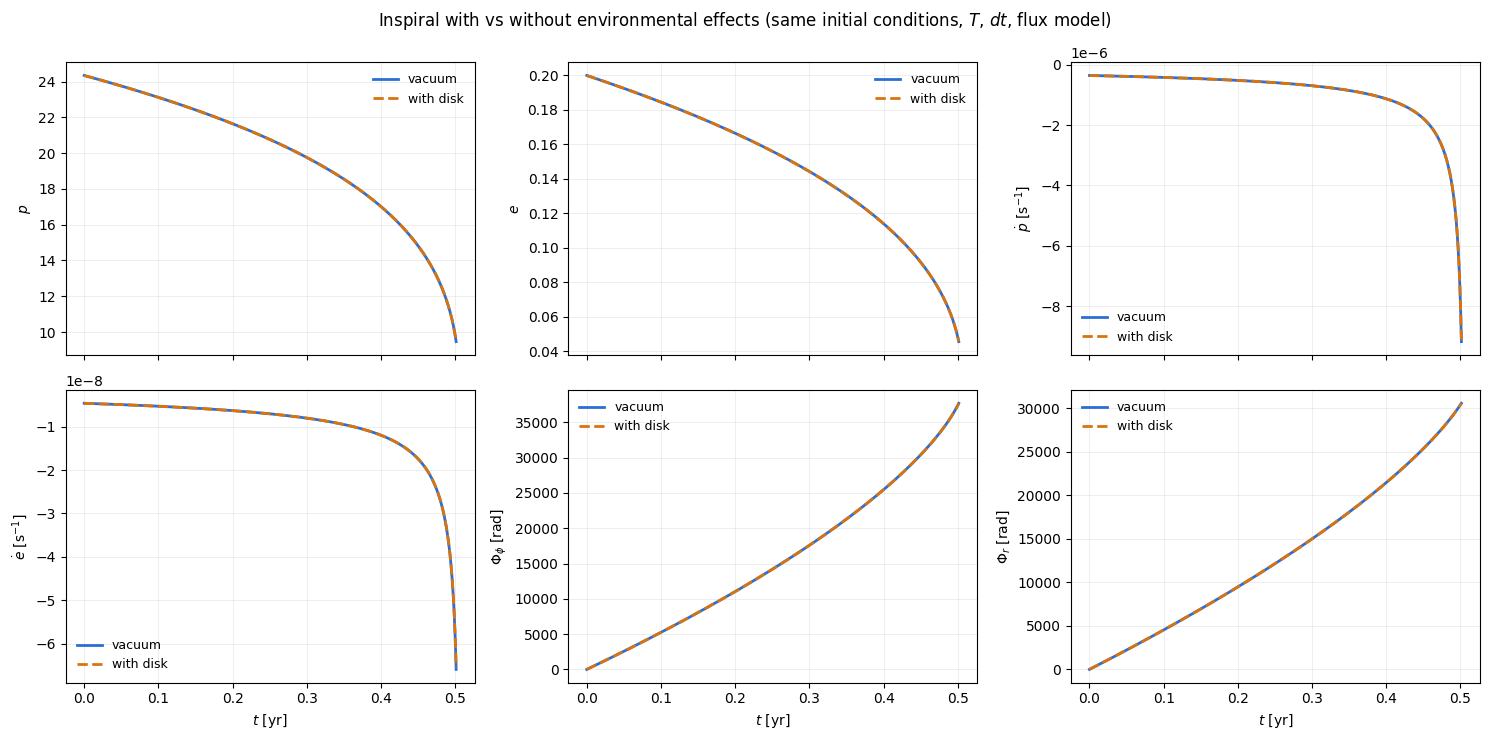

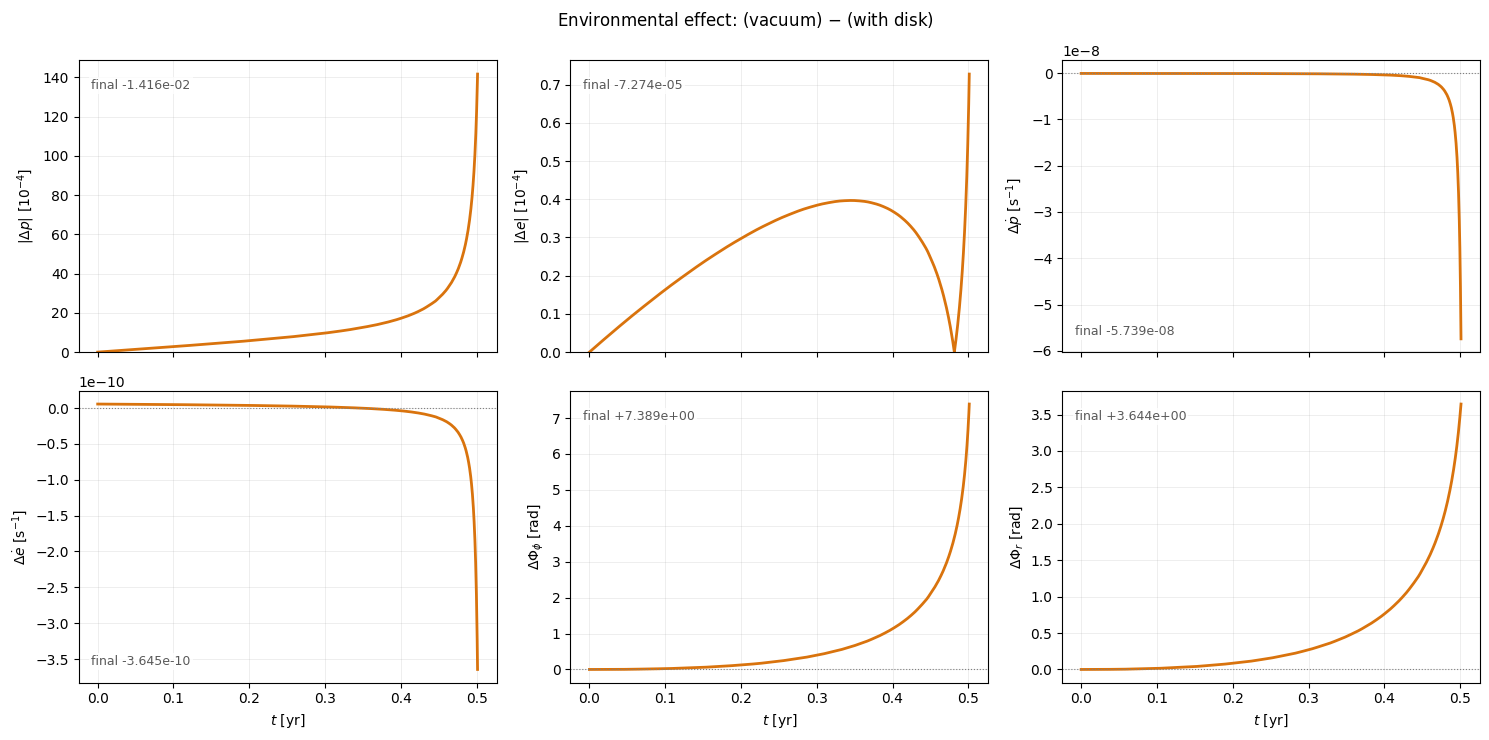

In [6]:
# ============================================================================
# Comparison between inspirals with and without environmental effects.
# Same (m1, m2, a, p0, e0, xI0), same T and dt, same flux model
# (KerrEccEqAccFlux).  The ONLY difference is the environmental arguments:
# [Sigma0, h0, Sigma_p] vs [].  KerrEccEqAccFlux with no extra arguments
# reduces exactly to KerrEccEqFlux, so this isolates the disk torque.
# ============================================================================

ENV_COLOR, VAC_COLOR = "#d9730d", "#2a6fd6"   # orange = with disk, blue = vacuum

# key, overlay label, difference label, y-axis scale, take |.| of the difference.
# Derivatives keep their sign -- the sign change in edot is physics (disk
# eccentricity damping handing over to the GW flux) and |.| hides it as a cusp.
PANELS = [("p",       r"$p$",                  r"$|\Delta p|$",        1e-4, True),
          ("e",       r"$e$",                  r"$|\Delta e|$",        1e-4, True),
          ("pdot",    r"$\dot p$ [s$^{-1}$]",  r"$\Delta\dot p$ [s$^{-1}$]", None, False),
          ("edot",    r"$\dot e$ [s$^{-1}$]",  r"$\Delta\dot e$ [s$^{-1}$]", None, False),
          ("Phi_phi", r"$\Phi_\phi$ [rad]",    r"$\Delta\Phi_\phi$ [rad]",  1e0,  False),
          ("Phi_r",   r"$\Phi_r$ [rad]",       r"$\Delta\Phi_r$ [rad]",     1e0,  False)]


def scaled_label(dlabel, scale):
    """Append the y-axis scale factor to a label, unless it is 1 or automatic."""
    if scale is None or scale == 1.0:
        return dlabel
    return f"{dlabel} [$10^{{{int(round(np.log10(scale)))}}}$]"


def run_trajectory(add_args, T, flux_class=KerrEccEqAccFlux):
    """One inspiral as a dict of arrays. Skips get_p_at_t, so it is cheap."""
    traj = EMRIInspiral(func=flux_class)
    out = traj(m1, m2, a, p0, e0, Y0, *add_args, T=T)
    return dict(t=out[0], p=out[1], e=out[2], xI=out[3],
                Phi_phi=out[4], Phi_theta=out[5], Phi_r=out[6])


def flux_along(traj_d, add_args, flux_class=KerrEccEqAccFlux):
    """dp/dt and de/dt in s^-1 at every trajectory point, from the ODE RHS.

    FEW integrates in tau = (m2/m1) * t/M, so evaluate_rhs returns the
    mass-ratio-stripped rate; multiply by eps / (M * MTSUN_SI) for per-second.
    """
    ode = flux_class()
    ode.add_fixed_parameters(m1, m2, a, additional_args=list(add_args) or None)
    to_per_sec = (m2 / m1) / (m1 * MTSUN_SI)
    pdot = np.empty_like(traj_d["p"])
    edot = np.empty_like(traj_d["e"])
    for i, (pi, ei, xi) in enumerate(zip(traj_d["p"], traj_d["e"], traj_d["xI"])):
        ydot = ode(np.array([pi, ei, xi, 0.0, 0.0, 0.0]))
        pdot[i], edot[i] = ydot[0] * to_per_sec, ydot[1] * to_per_sec
    return pdot, edot


def resample(t_src, y_src, t_new):
    """Cubic-spline a trajectory quantity onto a common time grid."""
    return CubicSpline(t_src, y_src)(t_new)


def compare_environment(T, add_args_env=None, n_grid=2000, make_plots=True):
    """Run the two inspirals, tabulate the differences, and plot them."""
    if add_args_env is None:
        add_args_env = env_tail(True)

    env = run_trajectory(add_args_env, T)
    vac = run_trajectory(env_tail(False), T)
    env["pdot"], env["edot"] = flux_along(env, add_args_env)
    vac["pdot"], vac["edot"] = flux_along(vac, env_tail(False))

    tc = np.linspace(0.0, min(env["t"][-1], vac["t"][-1]), n_grid)
    grid = {k: (resample(env["t"], env[k], tc), resample(vac["t"], vac[k], tc))
            for k, *_ in PANELS}

    print(f"[ENV] Sigma0 = {add_args_env[0]:.4e} (geometric), "
          f"h0 = {add_args_env[1]:g}, Sigma_p = {add_args_env[2]:g}")
    print(f"[RUN] T = {T:.6f} yr | env: N = {len(env['t'])}, "
          f"t_end = {env['t'][-1] / YRSID_SI:.6f} yr | vac: N = {len(vac['t'])}, "
          f"t_end = {vac['t'][-1] / YRSID_SI:.6f} yr")
    print(f"{'quantity':>9} {'env final':>15} {'vac final':>15} "
          f"{'final diff':>13} {'max |diff|':>13} {'final rel':>11}")
    for k, *_ in PANELS:
        ye, yv = grid[k]
        d = ye - yv
        rel = d[-1] / yv[-1] if yv[-1] != 0.0 else np.nan
        print(f"{k:>9} {ye[-1]:15.7e} {yv[-1]:15.7e} "
              f"{d[-1]:+13.5e} {np.abs(d).max():13.5e} {rel:+11.3e}")

    dphi = grid["Phi_phi"][0] - grid["Phi_phi"][1]
    dphr = grid["Phi_r"][0] - grid["Phi_r"][1]
    print(f"[DEPHASING] dPhi_phi = {dphi[-1]:+.6e} rad, "
          f"dPhi_r = {dphr[-1]:+.6e} rad over {T:.4f} yr")
    if max(abs(dphi[-1]), abs(dphr[-1])) < 1e-8:
        print("[WARN] the two inspirals are identical to round-off -- "
              "Sigma0 is too small to do anything at these parameters.")

    if make_plots:
        plot_overlay(tc / YRSID_SI, grid)
        plot_differences(tc / YRSID_SI, grid)
    return dict(t=tc, grid=grid, env=env, vac=vac, dPhi_phi=dphi, dPhi_r=dphr)


def _grid_of_axes(title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)
    fig.suptitle(title)
    for ax in axes[-1]:
        ax.set_xlabel("$t$ [yr]")
    for ax in axes.ravel():
        ax.grid(alpha=0.25, lw=0.6)
    return fig, axes.ravel()


def plot_overlay(t_yr, grid):
    """The two inspirals drawn on top of each other -- the absolute scale."""
    fig, axes = _grid_of_axes("Inspiral with vs without environmental effects "
                              "(same initial conditions, $T$, $dt$, flux model)")
    for ax, (k, label, *_) in zip(axes, PANELS):
        ye, yv = grid[k]
        ax.plot(t_yr, yv, color=VAC_COLOR, lw=2, label="vacuum")
        ax.plot(t_yr, ye, color=ENV_COLOR, lw=2, ls="--", label="with disk")
        ax.set_ylabel(label)
        ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()


def annotate_clear_of(ax, y, text):
    """Put the caption in whichever left corner the curve is not occupying."""
    lo, hi = ax.get_ylim()
    left = np.asarray(y)[: max(2, len(y) // 5)]
    top_is_busy = left.mean() > 0.5 * (lo + hi)
    ax.annotate(text, xy=(0.03, 0.06 if top_is_busy else 0.90),
                xycoords="axes fraction", fontsize=9, color="0.35",
                bbox=dict(fc="white", ec="none", alpha=0.8, pad=1.5))


def plot_differences(t_yr, grid):
    """(vacuum) - (with disk), which is where the effect is actually visible.

    Linear axis: a log axis is set by the zero crossings, which compresses the
    signal into the top decade.  p and e are drawn as |.|; the derivatives keep
    their sign so that the edot sign change reads as a crossing, not a cusp.
    """
    fig, axes = _grid_of_axes("Environmental effect: (vacuum) $-$ (with disk)")
    for ax, (k, _, dlabel, scale, use_abs) in zip(axes, PANELS):
        env, vac = grid[k]
        d = vac - env
        y = np.abs(d) if use_abs else d
        if scale is not None:
            y = y / scale
        ax.plot(t_yr, y, color=ENV_COLOR, lw=2)
        if use_abs:
            ax.set_ylim(bottom=0.0)
        else:
            ax.axhline(0.0, color="0.5", lw=0.8, ls=":")
        ax.set_ylabel(scaled_label(dlabel, scale))
        annotate_clear_of(ax, y, f"final {d[-1]:+.3e}")
    fig.tight_layout()
    plt.show()


cmp_out = compare_environment(T)


In [26]:
def build_waveform_response(T, dt, use_gpu=False, tdi_chan="AET"):
    sum_kwargs = dict(pad_output=True, odd_len=True)
    waveform_model = GenerateEMRIWaveform(FastKerrEccentricEquatorialAccretionFlux, sum_kwargs=sum_kwargs,
                                          return_list=False, use_gpu=use_gpu)
    t0 = 10000.0
    tdi_gen = "1st generation"
    order = 20
    index_lambda = 8  # phiS
    index_beta = 7    # qS
    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend="cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan=tdi_chan)
    return response


# SEF builds its own ResponseWrapper internally, so keep one dict and reuse it for both.
response_kwargs = dict(
    Tobs=T, t0=10000.0, dt=dt, index_lambda=8, index_beta=7, flip_hx=True,
    is_ecliptic_latitude=False, remove_garbage="zero",
    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
    force_backend="cuda12x" if use_gpu else "cpu",
    order=20, tdi="1st generation", tdi_chan={2: "AE", 3: "AET"}[nchannels])

waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,
                                            tdi_chan=response_kwargs["tdi_chan"])
print("[INFO] response built")

[INFO] response built


In [27]:
t_start = time.time()
waveform_gr = xp.array(waveform_response(*wave_params(False)))[0:nchannels, :]
waveform_env = xp.array(waveform_response(*wave_params(True)))[0:nchannels, :]
print(f"[INFO] both waveforms generated in {time.time() - t_start:.1f} s")

channels = [A1TDISens, E1TDISens, T1TDISens]
if nchannels == 3:
    noise_kwargs = [{"sens_fn": ch} for ch in channels]
elif nchannels == 2:
    noise_kwargs = [{"sens_fn": ch} for ch in channels[:2]]
else:
    raise ValueError(f"Unsupported number of channels: {nchannels}. Only 2 (A,E) or 3 (A,E,T) are supported.")

# PSD is built once, from the GR waveform, and used for both so the two are scored identically.
PSD_funcs = generate_PSD(
    waveform=waveform_gr,
    dt=dt,
    noise_PSD=get_sensitivity,
    channels=channels[:nchannels],
    noise_kwargs=noise_kwargs,
    use_gpu=use_gpu,
)
PSD_funcs_ = xp.array(PSD_funcs)
print("shape check - waveform:", xp.shape(waveform_gr), "PSD_funcs:", xp.shape(PSD_funcs_))


def make_freq_mask(n, dt, fmin, fmax):
    """Boolean mask over rfftfreq with the DC bin dropped, which is what inner_product wants."""
    f = xp.fft.rfftfreq(n, dt)
    return ((f > fmin) & (f < fmax))[1:]


N_fiducial = len(waveform_gr[0])
assert waveform_env.shape == waveform_gr.shape, "the two waveforms must be the same length to share a mask"
freq_mask = make_freq_mask(N_fiducial, dt, F_MIN, F_MAX)


def ip(a, b):
    v = inner_product(a, b, PSD_funcs_, dt, freq_mask=freq_mask, use_gpu=use_gpu)
    return float(v.get() if hasattr(v, "get") else v)


for label, h in [("GR ", waveform_gr), ("ENV", waveform_env)]:
    snr = np.sqrt(ip(h, h))
    print(f"[{label}] SNR: {snr:.6f}")
    for i in range(nchannels):
        v = inner_product(h[i:i + 1, ], h[i:i + 1, ], PSD_funcs_[i:i + 1, :], dt,
                          freq_mask=freq_mask, use_gpu=use_gpu)
        snr_i = np.sqrt(float(v.get() if hasattr(v, "get") else v))
        print(f"[{label}] SNR - Channel {i}: {snr_i:.6f}  ({100 * (snr_i / snr) ** 2:.2f}% of SNR^2)")

freq = np.fft.rfftfreq(N_fiducial, dt)
delta_f = freq[1] - freq[0]
n_kept = int(freq_mask.sum().get() if hasattr(freq_mask.sum(), "get") else freq_mask.sum())
print(f"[INFO] Frequency resolution delta_f: {delta_f:.6e} Hz, Number of frequency bins: {len(freq)}")
print(f"freq_max: {freq[-1]:.6f} Hz and Freq_min: {freq[1]:.6f} Hz")
print(f"[MASK] band [{F_MIN:.1e}, {F_MAX:.1e}] Hz keeps {n_kept:,d} / {len(freq) - 1:,d} bins "
      f"({100 * n_kept / (len(freq) - 1):.2f}%)")

[INFO] both waveforms generated in 0.1 s
shape check - waveform: (3, 3129540) PSD_funcs: (3, 1564770)
[GR ] SNR: 82.092292
[GR ] SNR - Channel 0: 60.732851  (54.73% of SNR^2)
[GR ] SNR - Channel 1: 54.829433  (44.61% of SNR^2)
[GR ] SNR - Channel 2: 6.663207  (0.66% of SNR^2)
[ENV] SNR: 82.098028
[ENV] SNR - Channel 0: 60.753194  (54.76% of SNR^2)
[ENV] SNR - Channel 1: 54.814290  (44.58% of SNR^2)
[ENV] SNR - Channel 2: 6.673023  (0.66% of SNR^2)
[INFO] Frequency resolution delta_f: 6.390716e-08 Hz, Number of frequency bins: 1564771
freq_max: 0.100000 Hz and Freq_min: 0.000000 Hz
[MASK] band [1.0e-05, 1.0e-01] Hz keeps 1,564,613 / 1,564,770 bins (99.99%)


In [28]:
snr_gr = np.sqrt(ip(waveform_gr, waveform_gr))
snr_env = np.sqrt(ip(waveform_env, waveform_env))
overlap = ip(waveform_gr, waveform_env) / (snr_gr * snr_env)
mismatch = 1.0 - overlap

# chi2 of the residual, the same quantity the CV runs report
resid = waveform_env - waveform_gr
chi2_resid = ip(resid, resid)

print(f"[OVL] SNR_GR   = {snr_gr:.6f}")
print(f"[OVL] SNR_ENV  = {snr_env:.6f}")
print(f"[OVL] overlap  = {overlap:.12f}")
print(f"[OVL] mismatch = {mismatch:.6e}")
print(f"[OVL] chi2 <r|r>          = {chi2_resid:.6e}")
print(f"[OVL] 2 SNR^2 (1-overlap) = {2 * snr_gr * snr_env * mismatch:.6e}   (consistency check)")

# where the difference comes from: accumulated orbital dephasing
traj = EMRIInspiral(func=SuperKludgeFlux)
out_gr = traj(m1, m2, a, p0, e0, Y0, *env_tail(False), T=T)
out_env = traj(m1, m2, a, p0, e0, Y0, *env_tail(True), T=T)
t_common = min(out_gr[0][-1], out_env[0][-1])
dPhi_phi = float(CubicSpline(out_env[0], out_env[4])(t_common) - CubicSpline(out_gr[0], out_gr[4])(t_common))
dPhi_r = float(CubicSpline(out_env[0], out_env[5])(t_common) - CubicSpline(out_gr[0], out_gr[5])(t_common))
print(f"[DEPH] dPhi_phi = {dPhi_phi:+.6e} rad over {t_common / YRSID_SI:.6f} yr "
      f"(total Phi_phi = {out_gr[4][-1]:.1f} rad)")
print(f"[DEPH] dPhi_r   = {dPhi_r:+.6e} rad")

[OVL] SNR_GR   = 82.092292
[OVL] SNR_ENV  = 82.098028
[OVL] overlap  = 0.997849584246
[OVL] mismatch = 2.150416e-03
[OVL] chi2 <r|r>          = 2.898598e+01
[OVL] 2 SNR^2 (1-overlap) = 2.898595e+01   (consistency check)
[DEPH] dPhi_phi = +0.000000e+00 rad over 0.495837 yr (total Phi_phi = 38325.4 rad)
[DEPH] dPhi_r   = +0.000000e+00 rad



## LM climb: fitting the environmental signal with a vacuum GR template

The injection is the environmentally perturbed waveform (`waveform_env`); the template is the
**same** waveform class with the disk arguments dropped, i.e. pure vacuum GR. We let the
template climb in its intrinsic parameters and see how much of the disk torque it can absorb.

Whatever overlap is left at the top of the climb is the part of the environmental signature
that vacuum GR genuinely cannot mimic, and the offset of the best fit from the injection is
the systematic bias.

The recipe is the standard one used by every CV script in `src/{EMRI,IMRI}`:
**CV climb -> (only if it stalls below target) one Nelder-Mead escape -> CV again.**

In [29]:

# ---------------------------------------------------------------------------
# Climb controls.  These are the shared values used by every CV script under
# src/{EMRI,IMRI}, kept identical so this run is comparable with those results.
# ---------------------------------------------------------------------------
NDELTA = 12                       # candidate stencil widths SEF trials per parameter
RECOMPUTE_DELTAS_EVERY = 5        # re-pick the stencil every N LM iterations
OVERLAP_TARGET = 0.9999999999     # stop climbing once the template is this close
LAMBDA0 = 1e-1                    # initial LM damping
LM_MAX_ITERS = 150                # outer Gauss-Newton steps
MAX_INNER = 30                    # damping retries allowed within one step
REL_TOL = 1e-9                    # stop when chi2 moves by less than this fraction
NM_MAXITER, NM_STEP = 1000, 2.0   # the Nelder-Mead escape, simplex in units of sigma

# The vacuum template is allowed to move only in the intrinsic parameters.
# a is held at its injected value (a = 0.0): the disk torque is a secular radial
# effect, and differentiating the Kerr flux grid across spin zero is asking for
# trouble.  The sky and orientation angles are held too -- a radial torque cannot
# be absorbed by moving the source on the sky.
params_to_infer = ["m1", "m2", "p0", "e0", "Phi_phi0", "Phi_r0"]
NPAR = len(params_to_infer)


def theta_to_wave_params(theta, environmental_included=False):
    """A climb vector -> the full positional argument list the response wants.

    Everything outside params_to_infer stays pinned at its injected value, so the
    template differs from the signal only in the parameters we are fitting and in
    the missing environmental tail.
    """
    p = dict(source_params)
    p.update(dict(zip(params_to_infer, theta)))
    return [p[n] for n in param_names_14] + env_tail(environmental_included)


# The climb starts at the injection itself.  There is no external MAP for this
# configuration, so 'from_injection' is the only seed available -- which is also
# the physically meaningful one here: it asks how far vacuum GR is dragged away
# from the truth by the disk.
theta_inj = np.array([source_params[n] for n in params_to_infer], dtype=float)

print(f"[LM  ] fitting {NPAR} parameters: {params_to_infer}")
print("[LM  ] seed (= injection): "
      + ", ".join(f"{n}={v:.6g}" for n, v in zip(params_to_infer, theta_inj)))
print("[LM  ] held fixed: " + str([n for n in param_names_14 if n not in params_to_infer]))

[LM  ] fitting 6 parameters: ['m1', 'm2', 'p0', 'e0', 'Phi_phi0', 'Phi_r0']
[LM  ] seed (= injection): m1=1e+06, m2=2000, p0=24.35, e0=0.05, Phi_phi0=1, Phi_r0=1
[LM  ] held fixed: ['a', 'xI0', 'dist', 'qS', 'phiS', 'qK', 'phiK', 'Phi_theta0']


In [30]:

# ---------------------------------------------------------------------------
# The scoring context: signal, template, overlap, chi2.
#
# The response, the PSD and ip() are all reused from the cells above, so every
# number printed here sits on exactly the same band and PSD as the overlap that
# was printed earlier -- chi2r(theta_inj) should reproduce the [OVL] chi2 <r|r>
# line exactly, which is the cheapest available check that this cell is wired up
# to the same problem.
# ---------------------------------------------------------------------------
s_signal = waveform_env           # the injection: disk torque included


def make_template(theta):
    """Vacuum-GR template at the climb vector theta (no disk arguments at all)."""
    args = theta_to_wave_params(theta, environmental_included=False)
    return xp.array(waveform_response(*args))[0:nchannels, :]


def ov(theta):
    """Noise-weighted, normalised overlap between the signal and the template."""
    h = make_template(theta)
    return ip(s_signal, h) / np.sqrt(ip(s_signal, s_signal) * ip(h, h))


def chi2r(theta):
    """<r|r> for the residual r = s - h(theta).

    A template that fails to generate is scored as unusable rather than raised,
    so one bad LM trial step cannot take the whole climb down with it.
    """
    try:
        r = s_signal - make_template(theta)
        return ip(r, r)
    except Exception as exc:
        print(f"    [warn] template failed at theta = {theta}: {type(exc).__name__}: {exc}")
        return 1e30


snr_signal = np.sqrt(ip(s_signal, s_signal))
print(f"[CTX ] SNR(signal)   = {snr_signal:.6f}")
print(f"[CTX ] overlap(seed) = {ov(theta_inj):.12f}")
print(f"[CTX ] chi2(seed)    = {chi2r(theta_inj):.6e}   (should match [OVL] chi2 above)")

[CTX ] SNR(signal)   = 82.098028
[CTX ] overlap(seed) = 0.997849584246
[CTX ] chi2(seed)    = 2.898598e+01   (should match [OVL] chi2 above)


In [31]:

# ---------------------------------------------------------------------------
# Derivatives.  StableEMRIFisher differentiates FEW's internals
# (deriv_type = "stable") rather than finite-differencing the response, which is
# what makes the Gauss-Newton step usable this close to plunge.
#
# SEF is built once here and called once per LM iteration.
#   F[0]  = the derivative waveforms dh/dtheta_j
#   F[-1] = the Fisher matrix  Gamma_ij = <d_i h | d_j h>
# ---------------------------------------------------------------------------
sef = StableEMRIFisher(
    waveform_class=FastKerrEccentricEquatorialAccretionFlux,
    waveform_class_kwargs=dict(sum_kwargs=dict(pad_output=True, odd_len=True)),
    waveform_generator=GenerateEMRIWaveform,
    waveform_generator_kwargs=dict(return_list=False),
    ResponseWrapper=ResponseWrapper,
    ResponseWrapper_kwargs=response_kwargs,
    stats_for_nerds=False, use_gpu=use_gpu, deriv_type="stable",
    noise_model=get_sensitivity, noise_kwargs=noise_kwargs,
    channels=channels[:nchannels],
    T=T, dt=dt, stability_plot=False, der_order=6, Ndelta=NDELTA,
    plunge_check=True, return_derivatives=True,
)


def fisher_derivs(theta, deltas=None):
    """(Gamma, dh/dtheta, deltas) for the VACUUM template at theta.

    add_param_args = env_apa(False) = {} is exactly what makes this the vacuum
    model: the template is handed no disk arguments, so SEF differentiates the
    same 14-parameter vacuum waveform that make_template() builds.

    Passing the previous `deltas` back in reuses the stencil, which is the
    expensive half of an SEF call; None forces a fresh stability scan.

    fmin/fmax are passed per call rather than our own freq_mask because SEF
    rebuilds the mask at its own waveform length, and plunge_check is free to
    shorten T -- a hard-coded mask would then be the wrong shape.
    """
    wp = dict(source_params)
    wp.update(dict(zip(params_to_infer, theta)))
    F = sef(
        wave_params={n: wp[n] for n in param_names_14},
        param_names=params_to_infer,
        add_param_args=env_apa(False),
        deltas=deltas,
        live_dangerously=False, stability_plot=False, der_order=8,
        Ndelta=(NDELTA if deltas is None else None),
        fmin=F_MIN, fmax=F_MAX,
    )
    return np.asarray(F[-1], dtype=float), xp.array(F[0]), sef.deltas

/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/multispline/spline.py:81: SyntaxWarning: invalid escape sequence '\l'
  Coefficient for the domain :math:`x_i \leq x \leq x_{i+1}`
/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/multispline/spline.py:408: SyntaxWarning: invalid escape sequence '\l'
  Coefficient for the domain :math:`x_i \leq x \leq x_{i+1}`
/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/multispline/spline.py:746: SyntaxWarning: invalid escape sequence '\l'
  Coefficient for the domain :math:`x_i \leq x \leq x_{i+1}`


KeyboardInterrupt: 

In [ ]:
# ---------------------------------------------------------------------------
# A "model" bundles everything a climb needs for ONE template family: how to
# build the template, how to score it against the signal, and how to get its
# derivatives.  Bundling it is what lets the LM/NM machinery below be written
# once and reused -- vacuum GR here, 0PA + PN deviation further down.
#
# The signal never changes: it is always the environmentally perturbed waveform.
# Only the model being fitted to it changes.
# ---------------------------------------------------------------------------
def make_model(name, signal, response, sef, tail, apa, names, seed):
    """Assemble one template family into the dict the climbers expect.

    name     : label used in the printouts
    signal   : the injection, scored against every template
    response : a ResponseWrapper built on this template's waveform class
    sef      : a StableEMRIFisher built on the SAME waveform class
    tail     : theta -> the extra POSITIONAL arguments after the standard 14
    apa      : theta -> the same extras as a dict, which is how SEF wants them
               (SEF appends them in dict order, so the order here is the wiring)
    names    : the parameters being fitted, in theta order.  Names outside
               param_names_14 (the deviation coefficients) are model arguments
               and reach the waveform through tail/apa instead.
    seed     : the starting vector
    """

    def base(theta):
        """The 14 standard parameters at theta; anything not fitted stays injected."""
        p = dict(source_params)
        p.update({n: v for n, v in zip(names, theta) if n in param_names_14})
        return p

    def template(theta):
        args = [base(theta)[n] for n in param_names_14] + list(tail(theta))
        return xp.array(response(*args))[0:nchannels, :]

    def overlap(theta):
        h = template(theta)
        return ip(signal, h) / np.sqrt(ip(signal, signal) * ip(h, h))

    def chi2(theta):
        """<r|r>.  A template that fails to generate is scored as unusable rather
        than raised, so one bad trial step cannot take the whole climb down."""
        try:
            r = signal - template(theta)
            return ip(r, r)
        except Exception as exc:
            print(f"    [warn] {name} template failed at {theta}: "
                  f"{type(exc).__name__}: {exc}")
            return 1e30

    def fisher(theta, deltas=None):
        """(Gamma, dh/dtheta, deltas) for THIS template at theta.

        Passing the previous `deltas` back in reuses the stencil, which is the
        expensive half of an SEF call; None forces a fresh stability scan.
        fmin/fmax go per call rather than our own freq_mask because plunge_check
        may shorten T, and a prebuilt mask would then be the wrong length.
        """
        p = base(theta)
        F = sef(wave_params={n: p[n] for n in param_names_14},
                param_names=list(names), add_param_args=apa(theta), deltas=deltas,
                live_dangerously=False, stability_plot=False, der_order=8,
                Ndelta=(NDELTA if deltas is None else None), fmin=F_MIN, fmax=F_MAX)
        return np.asarray(F[-1], dtype=float), xp.array(F[0]), sef.deltas

    return dict(name=name, names=list(names), npar=len(names), signal=signal,
                seed=np.asarray(seed, dtype=float), template=template,
                ov=overlap, chi2=chi2, fisher=fisher)


# The vacuum model reuses the response and the SEF built in the two cells above,
# so nothing here is a second copy of that setup.
vacuum_model = make_model(
    name="vacuum GR", signal=s_signal,
    response=waveform_response, sef=sef,
    tail=lambda theta: env_tail(False),     # no disk arguments at all
    apa=lambda theta: env_apa(False),       # ... and none for SEF either
    names=params_to_infer, seed=theta_inj)

print(f"[MODEL] {vacuum_model['name']}: fitting {vacuum_model['names']}")
print(f"[MODEL] overlap(seed) = {vacuum_model['ov'](vacuum_model['seed']):.12f}")

[MODEL] vacuum GR: fitting ['m1', 'm2', 'p0', 'e0', 'Phi_phi0', 'Phi_r0']
[MODEL] overlap(seed) = -0.290095286357


In [ ]:
def lm_climb(model, theta0, tag=""):
    """Adaptive Levenberg-Marquardt CV climb for any model.

    Each outer iteration is one Cutler-Vallisneri step, damped:

        delta = (Gamma + lam * diag Gamma)^-1 g ,    g_i = <d_i h | s - h>

    with Nielsen gain-ratio updates on lam: a step that lowers chi2 relaxes the
    damping, a step that does not raises it and is retried.

    Returns (theta, overlap, sigma), where sigma is the 1-sigma Fisher error --
    it is what scales the Nelder-Mead simplex in the next cell.
    """
    npar = model["npar"]
    cur = np.array(theta0, dtype=float)
    lam, nu, deltas, sigma = LAMBDA0, 2.0, None, np.ones(npar)

    for it in range(LM_MAX_ITERS):
        # fresh stencil every RECOMPUTE_DELTAS_EVERY steps, reused in between
        if it % RECOMPUTE_DELTAS_EVERY == 0:
            deltas = None
        G, dH, deltas = model["fisher"](cur, deltas)

        h = model["template"](cur)
        r = model["signal"] - h
        g = np.array([ip(dH[j], r) for j in range(npar)])
        sigma = np.sqrt(np.abs(np.diag(fishinv(cur[0], G, index_of_M=0))))

        chi2_now = ip(r, r)
        ov_now = ip(model["signal"], h) / np.sqrt(ip(model["signal"], model["signal"]) * ip(h, h))
        if ov_now > OVERLAP_TARGET:
            print(f"    CV{tag} it {it:>3}  target reached, ov = {ov_now:.12f}")
            break

        # inner loop: raise the damping until the step actually lowers chi2
        scale = np.abs(np.diag(G)) + 1e-30
        step, accepted, rel = np.zeros(npar), False, 0.0
        for _ in range(MAX_INNER):
            try:
                step = np.linalg.solve(G + lam * np.diag(scale), g)
            except np.linalg.LinAlgError:
                lam *= nu
                nu *= 2.0
                continue
            predicted = float(step @ (g + lam * scale * step))
            chi2_try = model["chi2"](cur + step)
            rho = (chi2_now - chi2_try) / predicted if predicted > 0 else -1.0
            if rho > 0.0:                                  # accept, relax the damping
                lam *= max(1.0 / 3.0, 1.0 - (2.0 * rho - 1.0) ** 3)
                nu = 2.0
                rel = (chi2_now - chi2_try) / chi2_now
                accepted = True
                break
            lam *= nu                                      # reject, damp harder
            nu *= 2.0

        print(f"    CV{tag} it {it:>3}  lam={lam:.1e}  ov={ov_now:.12f}  "
              f"chi2={chi2_now:.6e}  rel={rel:.2e}")

        if not accepted:
            # No amount of damping helped.  That is a basin problem, not a step
            # size problem -- which is what the NM escape below is for.
            print(f"    CV{tag} STALLED at iteration {it}")
            break

        cur = cur + step
        if rel < REL_TOL:
            print(f"    CV{tag} converged: chi2 moved by less than {REL_TOL:g}")
            break

    return cur, model["ov"](cur), sigma

In [ ]:
def nm_refine(model, theta0, sigma, maxiter=NM_MAXITER):
    """One Nelder-Mead escape, in units of the Fisher sigma.

    LM stalls wherever <dh/dtheta | r> ~ 0, and no choice of lam fixes that: the
    step vanishes for every damping.  NM searches in sigma-scaled coordinates so
    that every parameter takes steps of comparable statistical significance
    rather than comparable raw size (m1 ~ 1e6 against e0 ~ 0.04).

    The result is accepted ONLY if it improves the overlap, so this stage can
    never make the fit worse.
    """
    npar = model["npar"]
    simplex = np.vstack([np.zeros(npar)]
                        + [NM_STEP * np.eye(npar)[i] for i in range(npar)])
    res = minimize(lambda x: model["chi2"](theta0 + x * sigma), np.zeros(npar),
                   method="Nelder-Mead",
                   options=dict(initial_simplex=simplex, maxiter=maxiter,
                                xatol=1e-4, fatol=1e-4, adaptive=True))
    cand = theta0 + res.x * sigma
    ov_before, ov_after = model["ov"](theta0), model["ov"](cand)
    accepted = ov_after > ov_before
    print(f"    NM   nfev={res.nfev}  ov {ov_before:.12f} -> {ov_after:.12f}  "
          f"(accepted={accepted})")
    return cand if accepted else theta0

In [ ]:
def run_climb(model, theta0=None):
    """The standard recipe: CV -> (only if it stalls below target) NM -> CV.

    Returns a dict with every overlap along the way, so the summary below can
    show which stage actually bought the improvement.
    """
    theta0 = np.asarray(model["seed"] if theta0 is None else theta0, dtype=float)
    print("=" * 78)
    print(f"[{model['name']}] SNR = {snr_signal:.4f},  "
          f"overlap(seed) = {model['ov'](theta0):.12f}")

    theta, ov_after_lm1, sigma = lm_climb(model, theta0, tag="#1")

    ov_after_nm = None
    if ov_after_lm1 < OVERLAP_TARGET:
        theta = nm_refine(model, theta, sigma)
        ov_after_nm = model["ov"](theta)
        theta, _, sigma = lm_climb(model, theta, tag="#2")

    return dict(label=model["name"], names=model["names"],
                theta0=theta0, theta=theta, sigma=sigma,
                ov_start=float(model["ov"](theta0)), ov_after_lm1=float(ov_after_lm1),
                ov_after_nm=(None if ov_after_nm is None else float(ov_after_nm)),
                ov_final=float(model["ov"](theta)),
                chi2_start=float(model["chi2"](theta0)),
                chi2_final=float(model["chi2"](theta)))


def report_climb(res):
    """Copy-ready summary: overlaps, chi2, and the per-parameter systematic bias.

    The climb is seeded at the injection, so 'bias' is simply best fit - seed.
    For a deviation coefficient the injected value is zero by construction, so
    its 'bias' column IS the recovered deviation.
    """
    print("-" * 78)
    print(f"[{res['label']}] overlap  seed -> {res['ov_start']:.12f}")
    print(f"[{res['label']}]          LM#1 -> {res['ov_after_lm1']:.12f}")
    if res["ov_after_nm"] is not None:
        print(f"[{res['label']}]          NM   -> {res['ov_after_nm']:.12f}")
        print(f"[{res['label']}]          LM#2 -> {res['ov_final']:.12f}")
    gain = (1.0 - res["ov_start"]) / max(1.0 - res["ov_final"], 1e-300)
    print(f"[{res['label']}] mismatch {1 - res['ov_start']:.6e} -> "
          f"{1 - res['ov_final']:.6e}   ({gain:.2f}x reduction)")
    print(f"[{res['label']}] chi2     {res['chi2_start']:.6e} -> {res['chi2_final']:.6e}")
    print()
    print(f"{'param':>10} {'injected':>17} {'best fit':>17} {'bias':>15} "
          f"{'sigma':>13} {'bias/sigma':>11}")
    for j, name in enumerate(res["names"]):
        inj, bf, sg = res["theta0"][j], res["theta"][j], res["sigma"][j]
        print(f"{name:>10} {inj:>17.9e} {bf:>17.9e} {bf - inj:>+15.6e} "
              f"{sg:>13.5e} {(bf - inj) / sg:>+11.3f}")
    print()
    print("best-fit vector [" + ", ".join(f"{v:.10e}" for v in res["theta"]) + "]")


result_vacuum = run_climb(vacuum_model)
report_climb(result_vacuum)

[vacuum GR] SNR = 351.3474,  overlap(seed) = -0.290095286357
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3127547)
Computing SNR for parameters: (np.float64(1000000.0), np.float64(2000.0), 0.0, np.float64(24.35), np.float64(0.0125), 1.0, 16.344, 0.7853981633974483, 1.0471975511965976, 0.5235987755982988, 0.39269908169872414, np.float64(1.0), 0.0, np.float64(1.0))
Waveform Generated. SNR: 440.5572899933533
calculating stable deltas...
Time taken to compute stable deltas is 17.31360387802124 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.537548303604126 seconds
    CV#1 it   0  lam=3.3e-02  ov=-0.290095286357  chi2=4.073426e+05  rel=5.00e-01
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3127547)
Computing SNR for parameters: (np.float64(999999.5755474466), np.float64(2000.0020483768387), 0.0, np.float64(24.349994801455047), np.float64(0.012423601799810792)

In [ ]:
def build_waveform_response_PN_deviation(T, dt, use_gpu=False, tdi_chan="AET"):
    sum_kwargs = dict(pad_output=True, odd_len=True)
    waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform, sum_kwargs=sum_kwargs, return_list=False, use_gpu=use_gpu)
    t0 = 10000.0
    tdi_gen = "1st generation"
    order = 20
    index_lambda = 8  # phiS
    index_beta = 7    # qS
    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend="cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan=tdi_chan)
    return response


# SEF builds its own ResponseWrapper internally, so keep one dict and reuse it for both.
response_kwargs = dict(
    Tobs=T, t0=10000.0, dt=dt, index_lambda=8, index_beta=7, flip_hx=True,
    is_ecliptic_latitude=False, remove_garbage="zero",
    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
    force_backend="cuda12x" if use_gpu else "cpu",
    order=20, tdi="1st generation", tdi_chan={2: "AE", 3: "AET"}[nchannels])

waveform_response_PN_dev = build_waveform_response_PN_deviation(T=T, dt=dt, use_gpu=use_gpu,
                                            tdi_chan=response_kwargs["tdi_chan"])
print("[INFO] response built")

[INFO] response built


## Second model: fitting the same signal with a 0PA + 2.5PN-deviation template

The signal is unchanged -- still `waveform_env`, the disk-perturbed injection. What changes is
the template family. Instead of pure vacuum GR we now allow the template two extra
**2.5PN flux-deviation** coefficients, `C_p` and `C_e`, which add a correction to `pdot` and
`edot`. The question this asks is the one the rest of the project asks of post-adiabatic
physics: **can a PN flux deviation mimic an accretion-disk torque?**

If it can, the deviation absorbs the disk signature, the overlap climbs well past what vacuum
GR reached, and the parameter biases shrink back toward the injection. If it cannot, the
deviation is driven to ~0 and we recover the vacuum result -- vacuum GR is nested at
`C_p = C_e = 0`, so the deviation model can never do worse at its true optimum.

Two things to be aware of, both printed by the check cell below:

1. **The template is a different waveform class from the signal.** The disk lives in
   `KerrEccEqAccFlux`, which takes only `[Sigma0, h0, Sigma_p]`; the PN deviation lives in
   `SuperKludgeFlux`, which has no disk slots. So the template's *baseline* is SuperKludge's
   gauge-transformed adiabatic flux, not the accretion class's. Any difference between those
   two vacuum baselines is an extra systematic riding along with the disk, and the check cell
   measures it directly by overlapping the two vacuum waveforms.
2. **The secondary spin `chi2` was never supplied for this source.** It is assumed zero.

In [ ]:
# ---------------------------------------------------------------------------
# PN deviation wiring.  SuperKludgeFlux reads its additional_args POSITIONALLY:
#
#   [0] chi2 (secondary spin)  [1] evolve_1PA   [2] evolve_primary
#   [3] evolve_2PA             [4] deviation_included   <- master switch
#   [5] C_p = dev_1   [6] C_e = dev_2      <- 2.5PN, additive on pdot/edot
#   [7] del_0_p       [8] del_0_e          <- multiplicative family, held at 0
#
# Get the order wrong and the wrong model is fitted silently, so the tail and
# the SEF dict are written side by side here and nowhere else.
# ---------------------------------------------------------------------------
CHI2_SECONDARY = 0.0   # ASSUMPTION: the secondary spin was never supplied for this source
EVOLVE_1PA = False     # the injection is adiabatic + disk, so the baseline must be 0PA too


def pn_tail(theta):
    """The 9 extra POSITIONAL arguments, as ResponseWrapper wants them."""
    C_p, C_e = theta[-2], theta[-1]
    return [CHI2_SECONDARY, EVOLVE_1PA, False, False, True, C_p, C_e, 0.0, 0.0]


def pn_apa(theta):
    """The same 9 arguments as a dict, which is how SEF wants them.

    SEF appends them in dict order, so this order IS the slot assignment above.
    """
    C_p, C_e = theta[-2], theta[-1]
    return {"chi2": CHI2_SECONDARY, "evolve_1PA": EVOLVE_1PA, "evolve_primary": False,
            "evolve_2PA": False, "deviation_included": True,
            "dev_1": C_p, "dev_2": C_e, "del_0_p": 0.0, "del_0_e": 0.0}


# Same intrinsic parameters as the vacuum climb, plus the two deviation coefficients.
# They are seeded at zero, i.e. at GR: the climb has to earn any deviation it reports.
params_to_infer_pn = params_to_infer + ["dev_1", "dev_2"]
theta_inj_pn = np.concatenate([theta_inj, [0.0, 0.0]])

print(f"[PN  ] fitting {len(params_to_infer_pn)} parameters: {params_to_infer_pn}")
print(f"[PN  ] dev_1 = C_p (slot 5), dev_2 = C_e (slot 6), both seeded at 0.0 (= GR)")
print(f"[PN  ] ASSUMED secondary spin chi2 = {CHI2_SECONDARY}, evolve_1PA = {EVOLVE_1PA}")

[PN  ] fitting 8 parameters: ['m1', 'm2', 'p0', 'e0', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
[PN  ] dev_1 = C_p (slot 5), dev_2 = C_e (slot 6), both seeded at 0.0 (= GR)
[PN  ] ASSUMED secondary spin chi2 = 0.0, evolve_1PA = False


In [ ]:
# ---------------------------------------------------------------------------
# Baseline check.  The signal and this template come from DIFFERENT waveform
# classes, so before fitting anything we measure how far apart their vacuum
# limits already are.  At dev = 0 the PN template is plain SuperKludge 0PA, so
# overlapping it with the vacuum AccFlux waveform isolates the class difference
# with no disk and no deviation involved.
#
# Read it this way:
#   ov(SK 0PA, AccFlux vacuum) ~ 1   -> the two baselines agree; whatever the PN
#                                      climb gains is genuinely about the disk.
#   ov(SK 0PA, AccFlux vacuum) < 1   -> the PN fit is absorbing a class offset as
#                                      well as the disk, and the deviation it
#                                      reports is contaminated by that much.
# ---------------------------------------------------------------------------
h_sk_vacuum = xp.array(waveform_response_PN_dev(
    *([source_params[n] for n in param_names_14] + pn_tail(theta_inj_pn))))[0:nchannels, :]

assert h_sk_vacuum.shape == waveform_gr.shape, \
    f"length mismatch: SK {h_sk_vacuum.shape} vs AccFlux {waveform_gr.shape}"

ov_baseline = ip(waveform_gr, h_sk_vacuum) / np.sqrt(ip(waveform_gr, waveform_gr)
                                                     * ip(h_sk_vacuum, h_sk_vacuum))
ov_sk_vs_env = ip(s_signal, h_sk_vacuum) / np.sqrt(ip(s_signal, s_signal)
                                                   * ip(h_sk_vacuum, h_sk_vacuum))

print(f"[BASE] SNR(SuperKludge 0PA vacuum)      = {np.sqrt(ip(h_sk_vacuum, h_sk_vacuum)):.6f}")
print(f"[BASE] ov(SK 0PA, AccFlux vacuum)       = {ov_baseline:.12f}   "
      f"(mismatch {1 - ov_baseline:.6e})")
print(f"[BASE] ov(SK 0PA, environmental signal) = {ov_sk_vs_env:.12f}   "
      f"(mismatch {1 - ov_sk_vs_env:.6e})")
print(f"[BASE] for comparison, ov(AccFlux vacuum, environmental signal) = {overlap:.12f}")

[BASE] SNR(SuperKludge 0PA vacuum)      = 440.558110
[BASE] ov(SK 0PA, AccFlux vacuum)       = 0.999999999999   (mismatch 7.362999e-13)
[BASE] ov(SK 0PA, environmental signal) = -0.290094480367   (mismatch 1.290094e+00)
[BASE] for comparison, ov(AccFlux vacuum, environmental signal) = -0.290095286357


In [ ]:
# ---------------------------------------------------------------------------
# The PN model.  Same factory as the vacuum model, so the only differences are
# the ones that matter: a SuperKludge response, a SuperKludge SEF, the deviation
# wiring, and two more parameters in the fit vector.
# ---------------------------------------------------------------------------
sef_pn = StableEMRIFisher(
    waveform_class=SuperKludgeWaveform,
    waveform_class_kwargs=dict(sum_kwargs=dict(pad_output=True, odd_len=True)),
    waveform_generator=GenerateEMRIWaveform,
    waveform_generator_kwargs=dict(return_list=False),
    ResponseWrapper=ResponseWrapper,
    ResponseWrapper_kwargs=response_kwargs,
    stats_for_nerds=False, use_gpu=use_gpu, deriv_type="stable",
    noise_model=get_sensitivity, noise_kwargs=noise_kwargs,
    channels=channels[:nchannels],
    T=T, dt=dt, stability_plot=False, der_order=6, Ndelta=NDELTA,
    plunge_check=True, return_derivatives=True,
)

pn_model = make_model(
    name="0PA + PN deviation", signal=s_signal,
    response=waveform_response_PN_dev, sef=sef_pn,
    tail=pn_tail, apa=pn_apa,
    names=params_to_infer_pn, seed=theta_inj_pn)

print(f"[MODEL] {pn_model['name']}: fitting {pn_model['names']}")
print(f"[MODEL] overlap(seed) = {pn_model['ov'](pn_model['seed']):.12f}")
print(f"[MODEL] for comparison, vacuum seed overlap = "
      f"{vacuum_model['ov'](vacuum_model['seed']):.12f}")

[MODEL] 0PA + PN deviation: fitting ['m1', 'm2', 'p0', 'e0', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
[MODEL] overlap(seed) = -0.290094480367
[MODEL] for comparison, vacuum seed overlap = -0.290095286357


In [ ]:
# ---------------------------------------------------------------------------
# The PN climb, and the comparison that is the point of the whole exercise.
# ---------------------------------------------------------------------------
result_pn = run_climb(pn_model)
report_climb(result_pn)

# Vacuum GR is nested in this model at dev = 0, so at the true optimum the PN fit
# can only match or beat it.  A PN overlap BELOW the vacuum one is therefore not
# physics -- it is a convergence artifact on the flat dev = 0 ridge, and the cure
# is to re-seed from the vacuum best fit rather than to touch lam.
print()
print("=" * 78)
print(f"{'model':<22} {'overlap':>18} {'mismatch':>14} {'chi2':>14}")
for res in (result_vacuum, result_pn):
    print(f"{res['label']:<22} {res['ov_final']:>18.12f} "
          f"{1 - res['ov_final']:>14.6e} {res['chi2_final']:>14.6e}")

reduction = (1 - result_vacuum["ov_final"]) / max(1 - result_pn["ov_final"], 1e-300)
print(f"\nPN buys a {reduction:.2f}x mismatch reduction over vacuum GR.")
print(f"recovered deviation:  C_p = {result_pn['theta'][-2]:+.6e}  "
      f"(+-{result_pn['sigma'][-2]:.3e}),  "
      f"C_e = {result_pn['theta'][-1]:+.6e}  (+-{result_pn['sigma'][-1]:.3e})")

print("\nper-parameter bias, vacuum vs PN, in units of each fit's own sigma:")
print(f"{'param':>10} {'vacuum bias/sigma':>20} {'PN bias/sigma':>16}")
for j, name in enumerate(params_to_infer):
    v = (result_vacuum["theta"][j] - result_vacuum["theta0"][j]) / result_vacuum["sigma"][j]
    p = (result_pn["theta"][j] - result_pn["theta0"][j]) / result_pn["sigma"][j]
    print(f"{name:>10} {v:>+20.3f} {p:>+16.3f}")

[0PA + PN deviation] SNR = 351.3474,  overlap(seed) = -0.290094480367
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3127547)
Computing SNR for parameters: (np.float64(1000000.0), np.float64(2000.0), 0.0, np.float64(24.35), np.float64(0.0125), 1.0, 16.344, 0.7853981633974483, 1.0471975511965976, 0.5235987755982988, 0.39269908169872414, np.float64(1.0), 0.0, np.float64(1.0), 0.0, False, False, False, True, np.float64(0.0), np.float64(0.0), 0.0, 0.0)
Waveform Generated. SNR: 440.55810960703485
calculating stable deltas...
minimum relative error is greater than 1% for e0. Fisher may be unstable!
minimum relative error is greater than 1% for dev_2. Fisher may be unstable!
Time taken to compute stable deltas is 26.314819812774658 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.364318370819092 seconds
    CV#1 it   0  lam=3.3e-02  ov=-0.290094480367  chi2=4.073433e+05  rel=5.12e-01
B